# $\color{#6aa2eb}{\textbf{Regularization}}$

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

%pip install ISLP
from ISLP import load_data

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.3 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=32cddbae51eb8bbf79741d1127420c7ab90babcf64e00d9c0c8c26c93bfa4b48
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


## $\color{#76ddff}{\textbf{Exercise - regularization L1 vs L2}}$


Let's explore the Hitters dataset, which contains information about various features of baseball players (independent variables) and their salary (dependent variable).

In [2]:
from sklearn.preprocessing import StandardScaler

Hitters = load_data('Hitters').dropna()
X, y = Hitters.drop(['Salary', 'League', 'Division', 'NewLeague'], axis = 'columns'), Hitters['Salary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=41)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [3]:
X

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,325,9,3
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,313,381,20
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,37,113,7
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,1314,131,12


In [4]:
feature_names = X.columns

a) Build a linear regression model predicting the player's salary based on the remaining variables. Calculate the $R^2$ score on the training and test sets. Is there overfitting?

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)

y_pred_test = lr.predict(X_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"The R2 score on the training set is {r2_train}, and on the test set it is {r2_test}.")

The R2 score on the training set is 0.5267708995180856, and on the test set it is 0.3908927184283648.


Conclusion: We're dealing with overfitting ($R2$ is much bigger on the training dataset).


b) Now use regularized Ridge regression. Plot the coefficient values as a function of the regularization strength $\alpha$. Consider a wide range of $\alpha$, e.g., $0-10^4$.

In [6]:
alphas = np.logspace(0, 4, 200)

coefs = []
for a in alphas:
    ridge = Ridge(alpha=a, fit_intercept=False)
    ridge.fit(X_train, y_train)
    coefs.append(ridge.coef_)

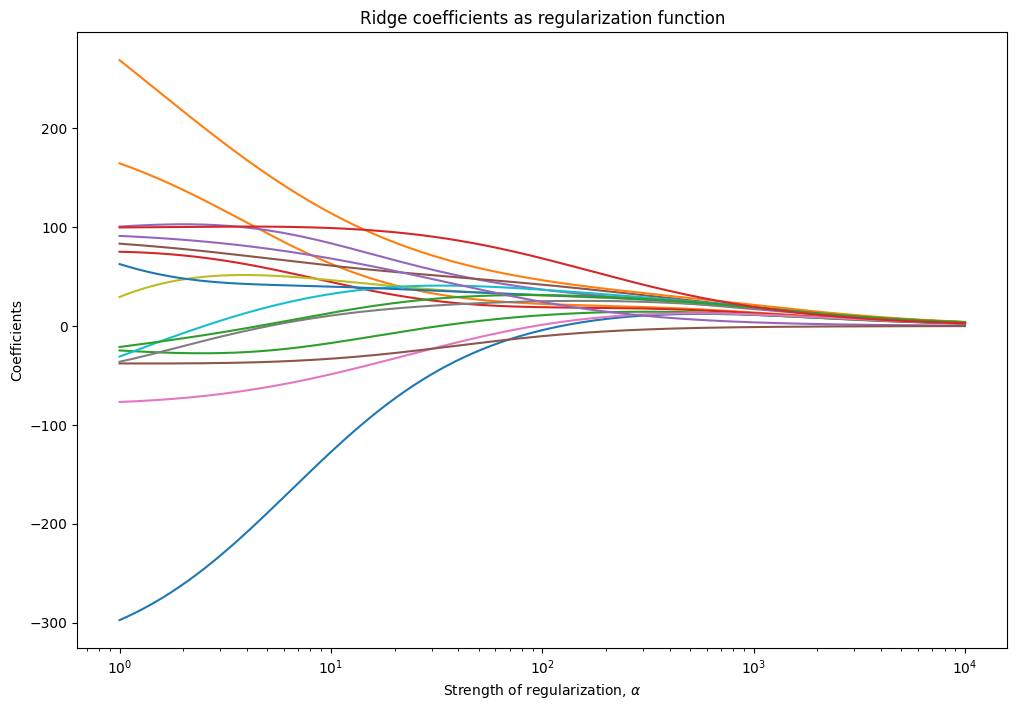

In [7]:
plt.figure(figsize = [12,8])

plt.plot(alphas, coefs)
plt.xscale("log")
plt.xlabel("Strength of regularization, " + r"$\alpha$")
plt.ylabel("Coefficients")
plt.title("Ridge coefficients as regularization function")
plt.show()

c) Calculate the $R^2$ score on the training and test sets for the Ridge regression from the previous point and plot them as a function of $\alpha$. Can you estimate the optimal regularization strength?

In [8]:
alphas_train_r2 = []
alphas_test_r2 = []

for a in alphas:
  ridge = Ridge(alpha=a)
  ridge.fit(X_train, y_train)

  y_pred_train_r = ridge.predict(X_train)
  r2_train_r = r2_score(y_train, y_pred_train_r)

  y_pred_test_r = ridge.predict(X_test)
  r2_test_r = r2_score(y_test, y_pred_test_r)

  alphas_train_r2.append(r2_train_r)
  alphas_test_r2.append(r2_test_r)

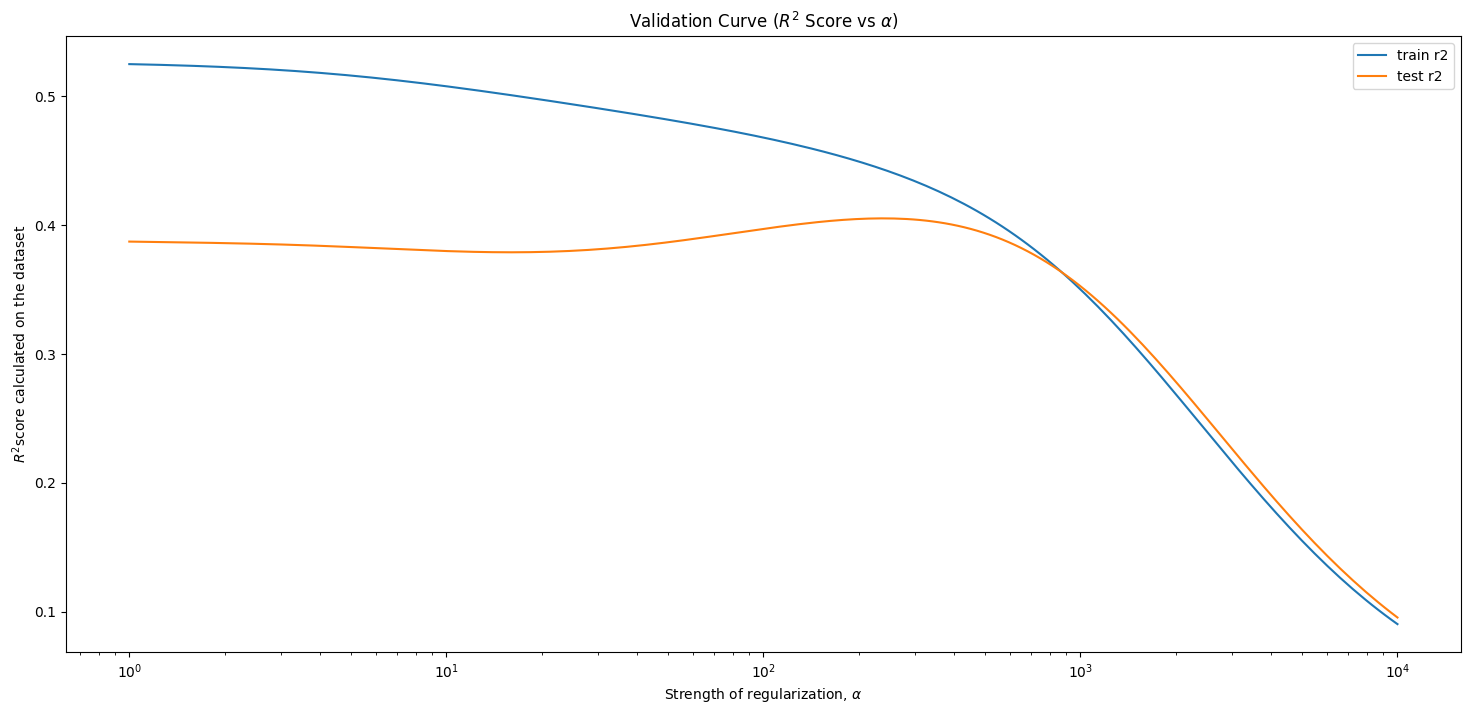

In [22]:
plt.figure(figsize = [18,8])
plt.plot(alphas, alphas_train_r2, label="train r2")
plt.plot(alphas, alphas_test_r2, label="test r2")
plt.xscale("log")
plt.xlabel("Strength of regularization, " + r"$\alpha$")
plt.ylabel("$R^2$" + "score calculated on the dataset")
plt.title("Validation Curve ($R^2$ Score vs "+ r"$\alpha$)")
plt.legend()
plt.show()

Conclusion: Optimal regularization strength is somewhere between $10^2$ and $10^3$, because that's where the $R^2$ score on the testing set is the highest.

d) Repeat steps b) and c) using `Lasso` regularization.

In [17]:
coefs = []
for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X_train, y_train)
    coefs.append(lasso.coef_)

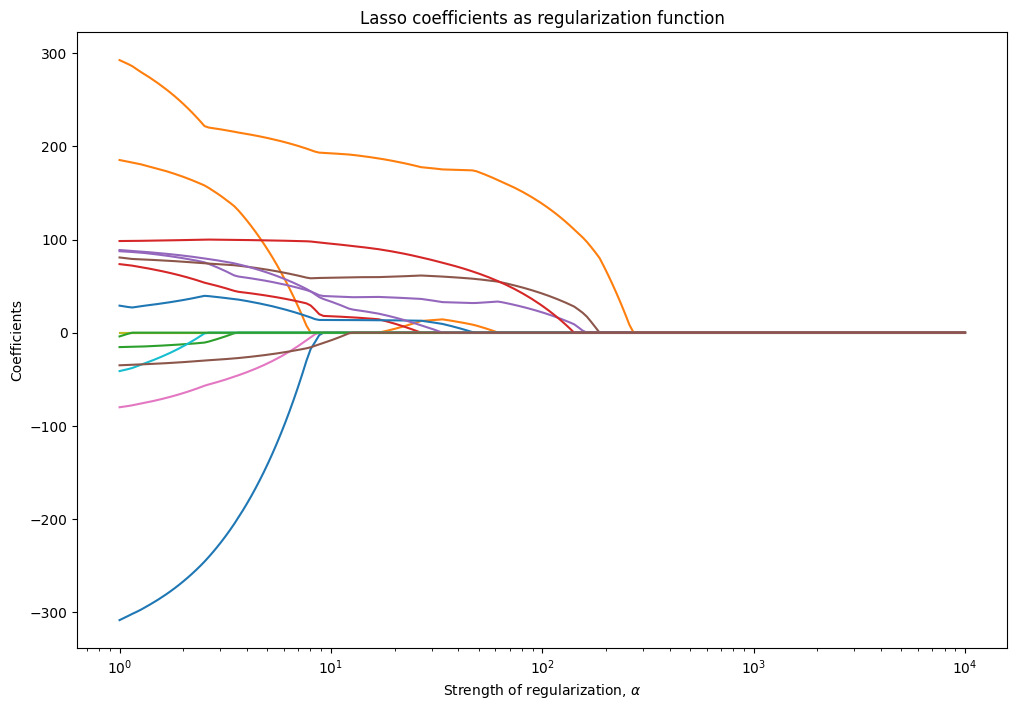

In [18]:
plt.figure(figsize = [12,8])

plt.plot(alphas, coefs)
plt.xscale("log")
plt.xlabel("Strength of regularization, " + r"$\alpha$")
plt.ylabel("Coefficients")
plt.title("Lasso coefficients as regularization function")
plt.show()

In [19]:
alphas_train_r2_l = []
alphas_test_r2_l = []

for a in alphas:
  lasso = Lasso(alpha=a)
  lasso.fit(X_train, y_train)

  y_pred_train_r = lasso.predict(X_train)
  r2_train_r = r2_score(y_train, y_pred_train_r)

  y_pred_test_r = lasso.predict(X_test)
  r2_test_r = r2_score(y_test, y_pred_test_r)

  alphas_train_r2_l.append(r2_train_r)
  alphas_test_r2_l.append(r2_test_r)

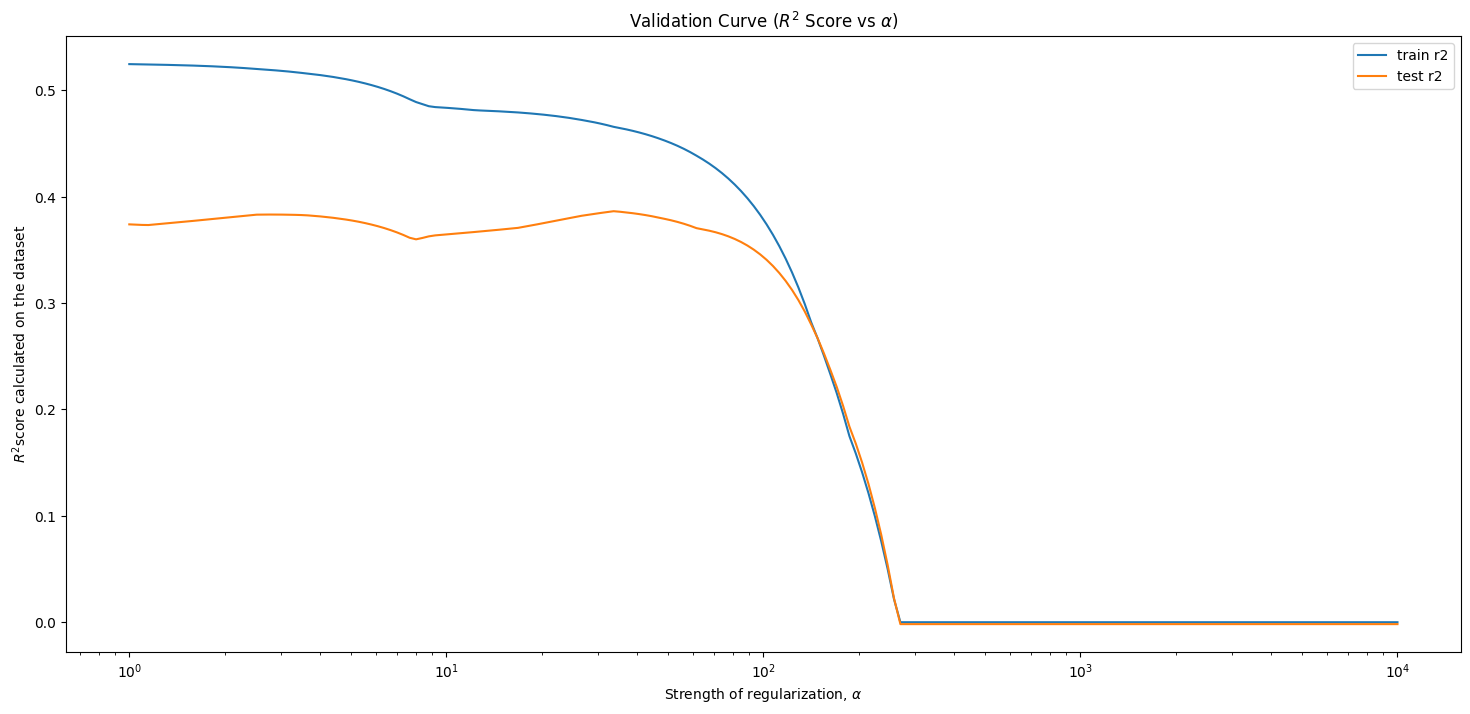

In [20]:
plt.figure(figsize = [18,8])
plt.plot(alphas, alphas_train_r2_l, label="train r2")
plt.plot(alphas, alphas_test_r2_l, label="test r2")
plt.xscale("log")
plt.xlabel("Strength of regularization, " + r"$\alpha$")
plt.ylabel("$R^2$" + "score calculated on the dataset")
plt.title("Validation Curve ($R^2$ Score vs "+ r"$\alpha$)")
plt.legend()
plt.show()

Conclusion: Optimal regularization strength is somewhere between $10^1$ and $10^2$, because that's where the $R^2$ score on the testing set is the highest.

e) For a reasonable regularization strength in the Lasso regression from the previous step – which features stop affecting the model's predictions? Are the same features also ignored by the Ridge regression?

In [24]:
alpha_lasso_id = np.argmax(alphas_test_r2_l)
alpha_lasso = alphas[alpha_lasso_id]

print(f"Optimal alpha is {alpha_lasso}")

lasso_optimal = Lasso(alpha=alpha_lasso)
lasso_optimal.fit(X_train, y_train)

print("\nIgnored features are:")

for i in range(len(lasso_optimal.coef_)):
  if lasso_optimal.coef_[i] == 0:
    print(feature_names[i])

Optimal alpha is 33.700643292719285

Ignored features are:
AtBat
HmRun
Runs
Years
CAtBat
CHits
CHmRun
CWalks
Errors


In [33]:
alpha_ridge_id = np.argmax(alphas_test_r2)
alpha_ridge = alphas[alpha_ridge_id]

print(f"Optimal alpha is {alpha_ridge}")

ridge_optimal = Ridge(alpha=alpha_ridge)
ridge_optimal.fit(X_train, y_train)

sorted_indexes = np.argsort(ridge_optimal.coef_)

print("\nFeatures sorted from lowest to highest coefficient:\n")
for i in sorted_indexes:
    print(f"{feature_names[i]}: {ridge_optimal.coef_[i]}")

Optimal alpha is 235.4286414322418

Features sorted from lowest to highest coefficient:

Errors: -4.638390710702434
AtBat: 8.696009434560063
Years: 10.33997294355448
Assists: 12.75391426526234
HmRun: 14.207252023509534
Runs: 18.05144741931097
Hits: 19.884114826137512
CAtBat: 25.00973192588591
CHits: 27.71898999616514
CRuns: 28.154803592791396
CWalks: 28.671874307653866
RBI: 28.704421560119748
CHmRun: 30.81830544376941
Walks: 33.64591895416201
CRBI: 35.81738864045405
PutOuts: 47.50003343056793


Conclusion: As we can see, both models 'ignored' similar features. There are some differences though: Ridge ignores 'Assists' (Lasso didn't) and Lasso ignored CHmRun and CWalks (Ridge didn't).